# Checkpoint 1 – Quem é o mago mais habilidoso do universo Harry Potter?

**Técnica utilizada:** Teste de Hipóteses (teste t pareado, unilateral) · **Nível de significância:** α = 0,10

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Guiroselli/cp1Nemec/blob/main/checkpoint_magos.ipynb)

## 1. Definição de "mais habilidoso"

Para mim, o mago mais habilidoso é aquele que **executa magia com a maior qualidade técnica**. Por isso criei o
**Índice de Habilidade (IH)** de cada execução:

$$IH = \frac{precisão + potência + controle}{3}$$

As três variáveis estão na mesma escala (0 a 100), então a média simples dá o mesmo peso a cada uma.

**Critérios de desempate** (usados somente se o teste principal não separar os candidatos):
1. Maior taxa de **sucesso**;
2. Menor taxa de **dano colateral**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ALPHA = 0.10

## 2. Carregando os dados

In [2]:
URL = "https://raw.githubusercontent.com/Guiroselli/cp1Nemec/main/checkpoint_magos_dados.csv"
import os
if os.path.exists("checkpoint_magos_dados.csv"):
    df = pd.read_csv("checkpoint_magos_dados.csv")   # arquivo enviado para o Colab
else:
    df = pd.read_csv(URL)                            # lê direto do GitHub

df.head()

,execucao_id,prova_id,mago,categoria,tarefa,dificuldade,pressao,resistencia_alvo,alvo_movel,contexto,tempo_execucao_s,precisao_pct,potencia_pct,controle_pct,sucesso,dano_colateral
0,E00001,P001,Albus Dumbledore,Ataque,Expelliarmus,1,10,1,0,duelo_real,11.08,83.18,83.76,83.17,1,0
1,E00002,P002,Albus Dumbledore,Ataque,Estupefaca,3,7,9,0,missao,14.97,77.64,76.94,81.93,1,0
2,E00003,P003,Albus Dumbledore,Ataque,Bombarda,4,3,4,0,treino,13.89,79.25,88.36,85.62,1,0
3,E00004,P004,Albus Dumbledore,Ataque,Confringo,4,9,8,0,duelo_real,13.79,85.30,87.36,81.13,0,0
4,E00005,P005,Albus Dumbledore,Ataque,Expelliarmus,2,4,9,1,exame,14.48,81.97,81.01,78.82,1,0


In [3]:
print(df.shape)
print("Magos:", df['mago'].nunique(), "| Provas:", df['prova_id'].nunique())
# Cada prova (mesma condição experimental) foi feita pelos 12 magos -> dados PAREADOS
df.groupby('prova_id')['mago'].nunique().value_counts()

(1440, 16)
Magos: 12 | Provas: 120


mago
12    120
Name: count, dtype: int64

## 3. Índice de Habilidade

In [4]:
df['IH'] = df[['precisao_pct', 'potencia_pct', 'controle_pct']].mean(axis=1)

resumo = (df.groupby('mago')
            .agg(IH_media=('IH', 'mean'), IH_desvio=('IH', 'std'),
                 taxa_sucesso=('sucesso', 'mean'), taxa_dano=('dano_colateral', 'mean'))
            .sort_values('IH_media', ascending=False))
resumo.round(3)

,IH_media,IH_desvio,taxa_sucesso,taxa_dano
mago,,,,
Albus Dumbledore,82.150,2.932,0.783,0.050
Severus Snape,81.515,3.561,0.875,0.042
Hermione Granger,80.987,3.058,0.775,0.025
Gellert Grindelwald,80.744,3.937,0.775,0.092
Lord Voldemort,79.983,4.506,0.733,0.267
Filius Flitwick,79.751,4.525,0.683,0.017
Minerva McGonagall,79.673,4.373,0.733,0.025
Kingsley Shacklebolt,78.243,3.640,0.583,0.017
Remus Lupin,77.174,3.455,0.575,0.025


C:\Users\guilh_bhuqvtz\AppData\Local\Temp\ipykernel_20072\4017612430.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df.loc[df['mago'] == m, 'IH'] for m in ordem], vert=False, labels=ordem)


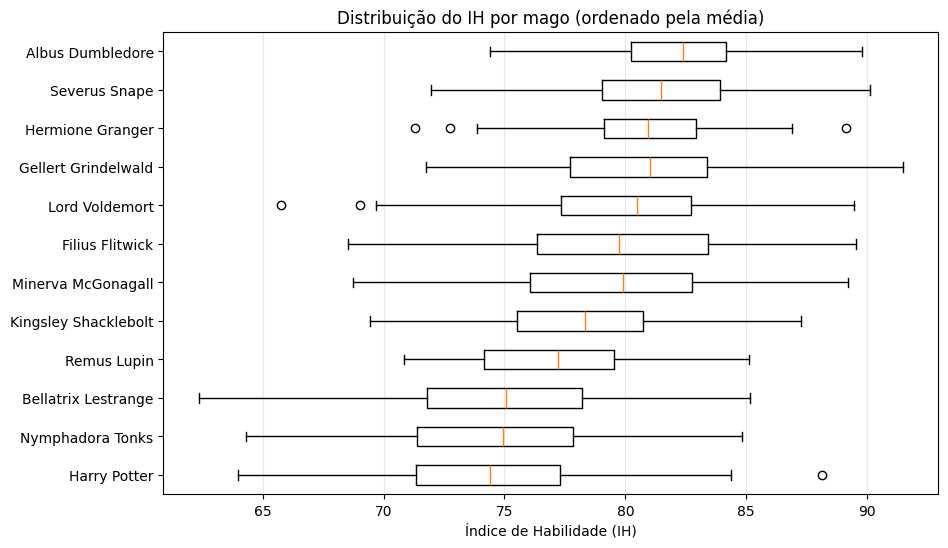

In [5]:
ordem = resumo.index
plt.figure(figsize=(10, 6))
plt.boxplot([df.loc[df['mago'] == m, 'IH'] for m in ordem], vert=False, labels=ordem)
plt.gca().invert_yaxis()
plt.xlabel('Índice de Habilidade (IH)')
plt.title('Distribuição do IH por mago (ordenado pela média)')
plt.grid(axis='x', alpha=.3)
plt.show()

## 4. Estratégia do teste

Como são **12 magos**, não faz sentido comparar todos contra todos sem direção. A estratégia é:

1. Ordenar os magos pela média do IH e escolher o **líder** (candidato a melhor).
2. Como **todos os magos fizeram as mesmas 120 provas** (`prova_id`), as amostras são **dependentes** →
   uso o **teste t pareado** (compara a diferença de IH prova a prova, eliminando o efeito da dificuldade de cada prova).
3. Testar o líder contra cada um dos outros 11 magos, com teste **unilateral**:

- **H0:** μ_dif ≤ 0 (o líder NÃO é melhor que o mago comparado)
- **H1:** μ_dif > 0 (o líder é melhor que o mago comparado)

onde dif = IH_líder − IH_outro em cada prova.

4. Se rejeitarmos H0 contra **todos** (p-valor < 0,10), o líder é o mais habilidoso.
   Os magos contra os quais H0 **não** for rejeitada ficam **empatados** com o líder e vão para os critérios de desempate.

Com n = 120 provas, pelo Teorema Central do Limite a média das diferenças tem distribuição aproximadamente normal, o que justifica o teste t.

In [6]:
ih = df.pivot(index='prova_id', columns='mago', values='IH')
lider = resumo.index[0]
print('Líder pela média do IH:', lider)

linhas = []
for mago in resumo.index[1:]:
    dif = ih[lider] - ih[mago]
    t, p = stats.ttest_rel(ih[lider], ih[mago], alternative='greater')
    linhas.append({'comparado_com': mago, 'dif_media': dif.mean(), 't': t, 'p_valor': p,
                   'decisao': 'Rejeita H0 (líder é melhor)' if p < ALPHA else 'Não rejeita H0 (empate)'})

resultado = pd.DataFrame(linhas)
resultado.round(5)

Líder pela média do IH: Albus Dumbledore


,comparado_com,dif_media,t,p_valor,decisao
0,Severus Snape,0.63478,1.43062,0.07758,Rejeita H0 (líder é melhor)
1,Hermione Granger,1.16253,3.12707,0.00111,Rejeita H0 (líder é melhor)
2,Gellert Grindelwald,1.40539,3.60298,0.00023,Rejeita H0 (líder é melhor)
3,Lord Voldemort,2.16694,5.18861,0.00000,Rejeita H0 (líder é melhor)
4,Filius Flitwick,2.39878,5.52091,0.00000,Rejeita H0 (líder é melhor)
5,Minerva McGonagall,2.47647,5.84142,0.00000,Rejeita H0 (líder é melhor)
6,Kingsley Shacklebolt,3.90644,10.63922,0.00000,Rejeita H0 (líder é melhor)
7,Remus Lupin,4.97575,13.09968,0.00000,Rejeita H0 (líder é melhor)
8,Bellatrix Lestrange,7.34414,16.18253,0.00000,Rejeita H0 (líder é melhor)
9,Nymphadora Tonks,7.47347,19.49535,0.00000,Rejeita H0 (líder é melhor)


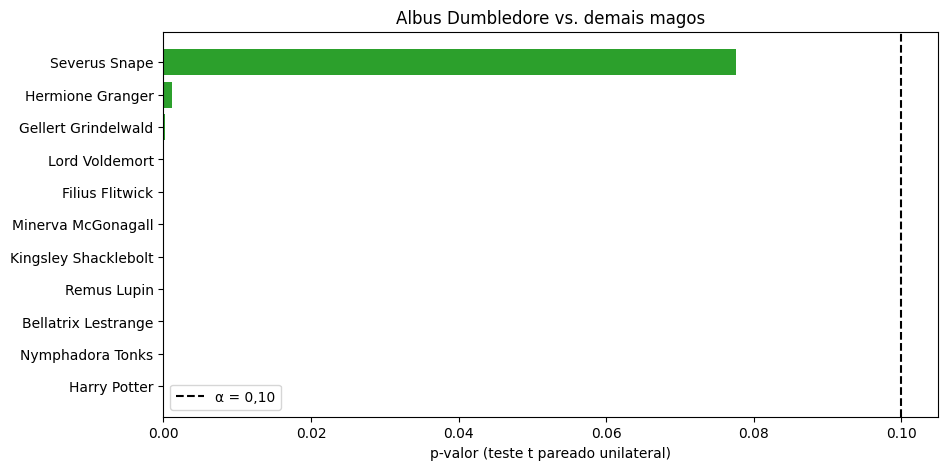

In [7]:
plt.figure(figsize=(10, 5))
cores = ['tab:green' if p < ALPHA else 'tab:red' for p in resultado['p_valor']]
plt.barh(resultado['comparado_com'], resultado['p_valor'], color=cores)
plt.axvline(ALPHA, color='k', ls='--', label='α = 0,10')
plt.gca().invert_yaxis()
plt.xlabel('p-valor (teste t pareado unilateral)')
plt.title(f'{lider} vs. demais magos')
plt.legend()
plt.show()

## 5. Desempate (aplicado apenas se houver empate)

In [8]:
empatados = [lider] + resultado.loc[resultado['p_valor'] >= ALPHA, 'comparado_com'].tolist()

if len(empatados) == 1:
    print(f'Não houve empate: {lider} foi significativamente superior a todos os outros 11 magos.')
else:
    print('Empatados no IH:', empatados)
    print(resumo.loc[empatados, ['taxa_sucesso', 'taxa_dano']])
    suc = df.pivot(index='prova_id', columns='mago', values='sucesso')
    dano = df.pivot(index='prova_id', columns='mago', values='dano_colateral')
    # Sub-critério 1: sucesso (teste t pareado bilateral entre os empatados)
    for a in empatados:
        for b in empatados:
            if a < b:
                print(a, 'x', b, '| sucesso p =', round(stats.ttest_rel(suc[a], suc[b]).pvalue, 4),
                      '| dano p =', round(stats.ttest_rel(dano[a], dano[b]).pvalue, 4))

Não houve empate: Albus Dumbledore foi significativamente superior a todos os outros 11 magos.


## 6. Conclusão

Com α = 0,10, o teste t pareado unilateral rejeitou H0 em todas as 11 comparações. O menor valor de diferença foi
contra **Severus Snape** (p ≈ 0,078 < 0,10) e todos os demais tiveram p-valores muito menores.

**Resultado: Albus Dumbledore é o mago mais habilidoso** segundo o critério de qualidade técnica (média de precisão,
potência e controle). Como não houve empate, os critérios de desempate não precisaram ser usados.